# Final Project

## 1. 数据预处理
#### 初步预览 & 一二阶差分

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

train_df=pd.read_csv('train_data.csv')
test_df=pd.read_csv('test_data.csv')

for col in["Current", "gpuUsage", "cpuUsage"]:
    train_df[f"{col}_diff1"] = train_df.groupby("sample_id")[col].diff(1)
    test_df[f"{col}_diff1"] = test_df.groupby("sample_id")[col].diff(1)
    train_df[f"{col}_diff2"] = train_df.groupby("sample_id")[col].diff(2)
    test_df[f"{col}_diff2"] = test_df.groupby("sample_id")[col].diff(2)
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

print("Training Data Info:")
print(train_df.info())
print("train_df.describe()")
print(train_df.describe())
print("Testing Data Info:")
print(test_df.info())
print("test_df.describe()")
print(test_df.describe())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   sample_id       120000 non-null  int64  
 1   time_idx        120000 non-null  int64  
 2   Current         120000 non-null  float64
 3   gpuUsage        120000 non-null  float64
 4   cpuUsage        120000 non-null  float64
 5   EyeQuality      120000 non-null  float64
 6   DecodeErrCount  120000 non-null  int64  
 7   miniFps         120000 non-null  float64
 8   label           120000 non-null  int64  
 9   Current_diff1   120000 non-null  float64
 10  Current_diff2   120000 non-null  float64
 11  gpuUsage_diff1  120000 non-null  float64
 12  gpuUsage_diff2  120000 non-null  float64
 13  cpuUsage_diff1  120000 non-null  float64
 14  cpuUsage_diff2  120000 non-null  float64
dtypes: float64(11), int64(4)
memory usage: 13.7 MB
None
train_df.describe()
          

In [2]:
time_series_cols=['sample_id','time_idx','Current','gpuUsage','cpuUsage','Current_diff1','gpuUsage_diff1','cpuUsage_diff1','Current_diff2','gpuUsage_diff2','cpuUsage_diff2','label']
times_train=train_df[time_series_cols]
times_test=test_df[time_series_cols]

cross_section_cols=['sample_id','EyeQuality','DecodeErrCount','miniFps','label']
cross_train=train_df[cross_section_cols]
cross_test=test_df[cross_section_cols]

y_train=train_df['label']
y_test=test_df['label']

#### 截面数据处理

Cross_sectional Data Info:


C:\Users\yuche\AppData\Local\Temp\ipykernel_13316\1523455078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cross_train.drop_duplicates(subset=['sample_id'], keep='first', inplace=True)
C:\Users\yuche\AppData\Local\Temp\ipykernel_13316\1523455078.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cross_test.drop_duplicates(subset=['sample_id'], keep='first', inplace=True)


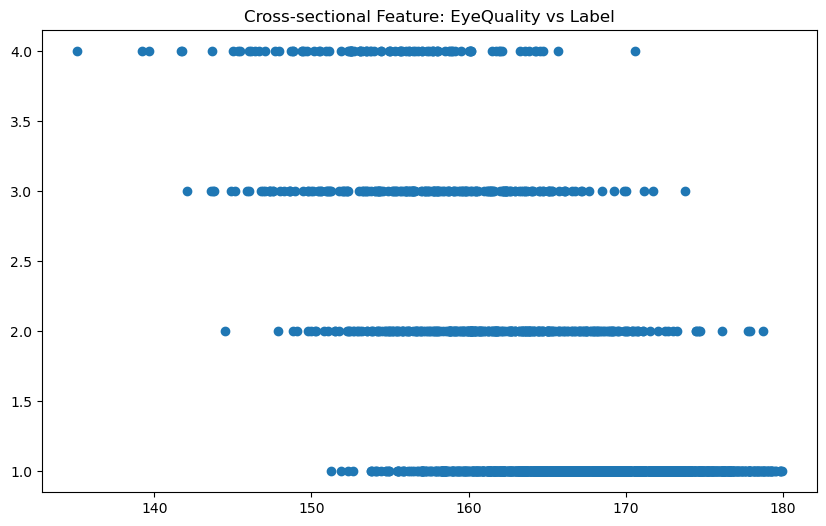

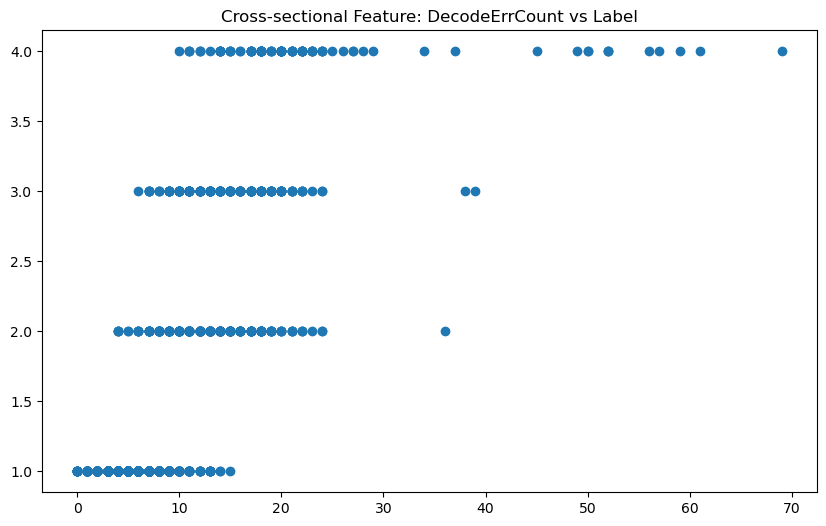

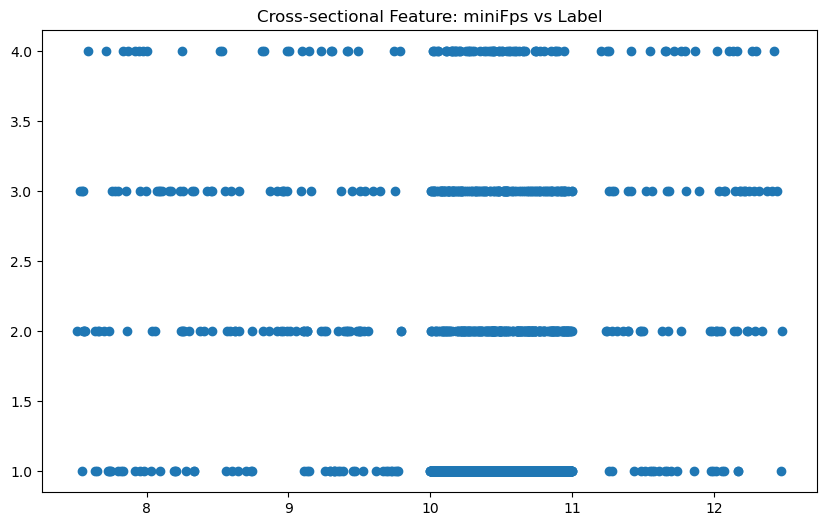

In [3]:
print("Cross_sectional Data Info:")
cross_train.drop_duplicates(subset=['sample_id'], keep='first', inplace=True)
cross_test.drop_duplicates(subset=['sample_id'], keep='first', inplace=True)

cross_train.reset_index(drop=True, inplace=True)
cross_test.reset_index(drop=True, inplace=True)

def plot_cross_sectional_feature_vs_label(feature_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(x=feature_name, y='label', data=cross_train)
    plt.title(f'Cross-sectional Feature: {feature_name} vs Label')
    plt.show()
for feature in ['EyeQuality', 'DecodeErrCount', 'miniFps']:
    plot_cross_sectional_feature_vs_label(feature)

In [4]:
cross_train.describe()

,sample_id,EyeQuality,DecodeErrCount,miniFps,label
count,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000
mean,1000.500000,165.617486,8.4530,10.398522,1.500000
std,577.494589,7.254305,6.3631,0.692035,0.866242
min,1.000000,135.084860,0.0000,7.510381,1.000000
25%,500.750000,161.110687,5.0000,10.188627,1.000000
50%,1000.500000,166.233942,7.0000,10.472957,1.000000
75%,1500.250000,171.049208,11.0000,10.760410,2.000000
max,2000.000000,179.918214,69.0000,12.475154,4.000000


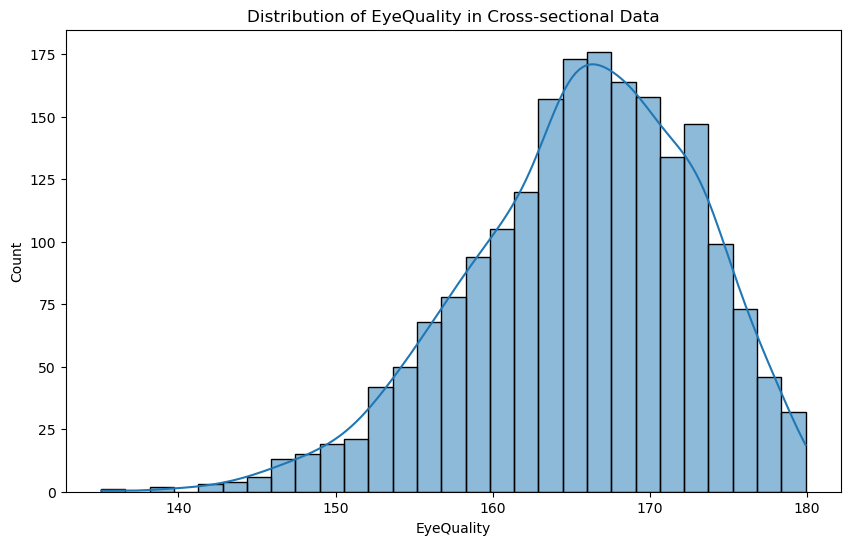

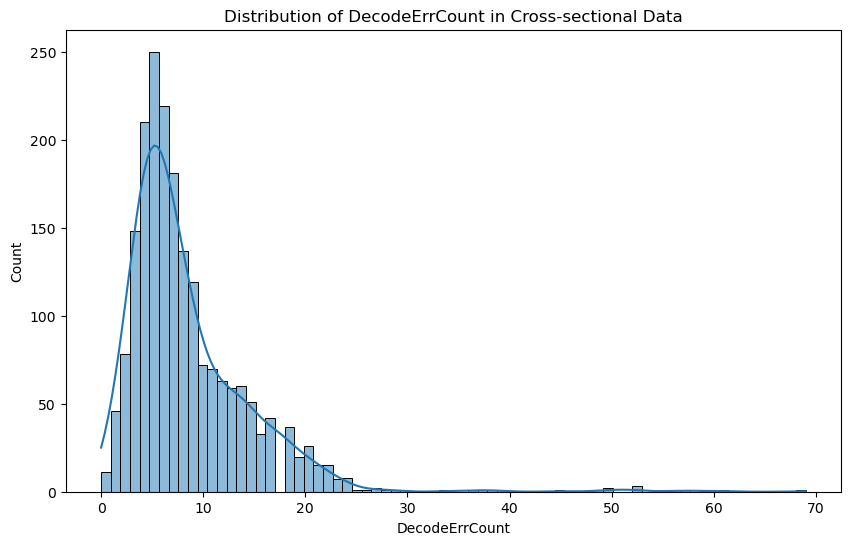

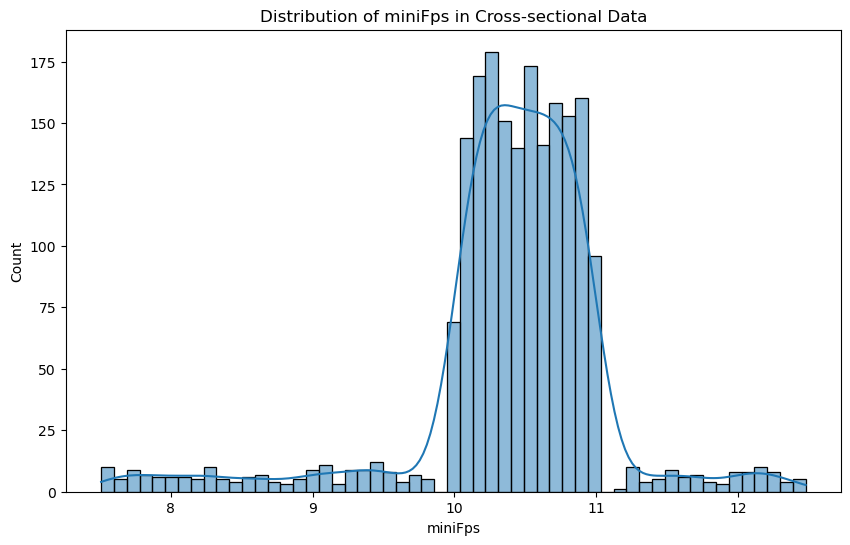

In [5]:
#截面数据的分布观察
for feature in ['EyeQuality', 'DecodeErrCount', 'miniFps']:
    plt.figure(figsize=(10, 6))
    sns.histplot(cross_train[feature], kde=True)
    plt.title(f'Distribution of {feature} in Cross-sectional Data')
    plt.show()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cross_train_scaled = cross_train.copy()
cross_test_scaled = cross_test.copy()
cross_train_scaled[['EyeQuality', 'DecodeErrCount', 'miniFps']] = scaler.fit_transform(cross_train[['EyeQuality', 'DecodeErrCount', 'miniFps']])
cross_test_scaled[['EyeQuality', 'DecodeErrCount', 'miniFps']] = scaler.fit_transform(cross_test[['EyeQuality', 'DecodeErrCount', 'miniFps']])

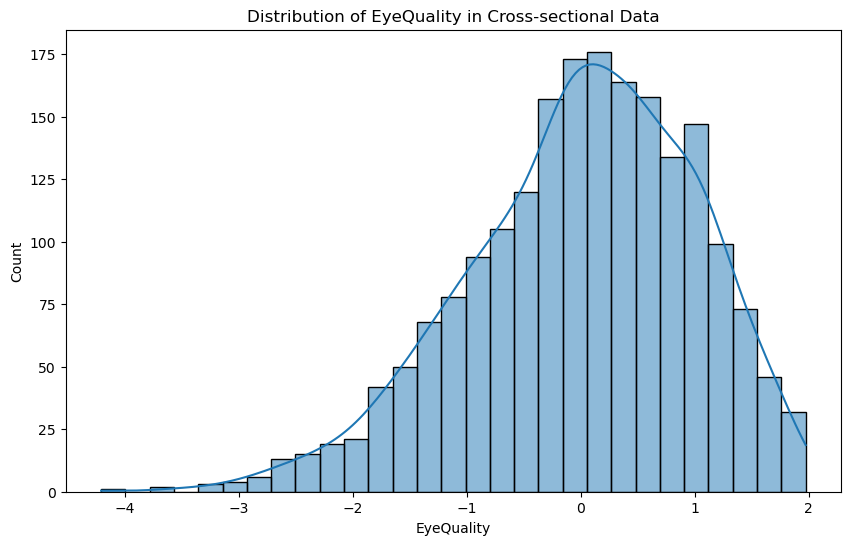

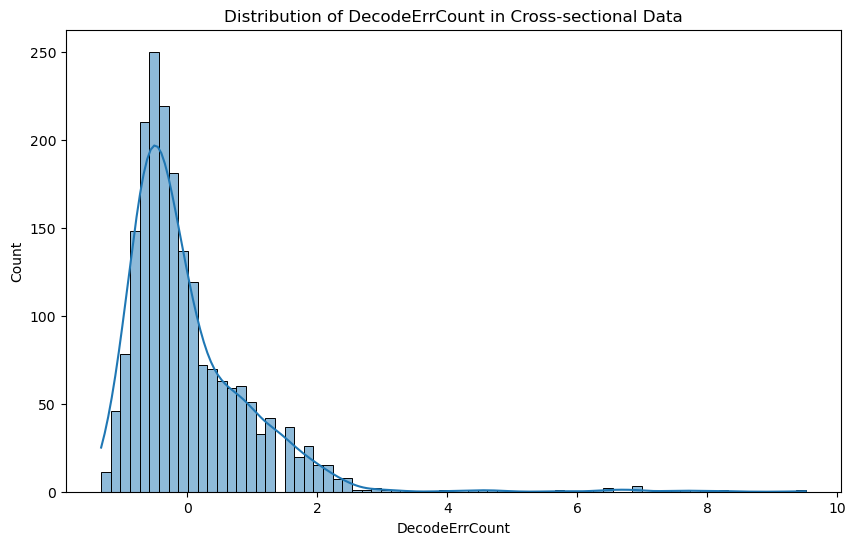

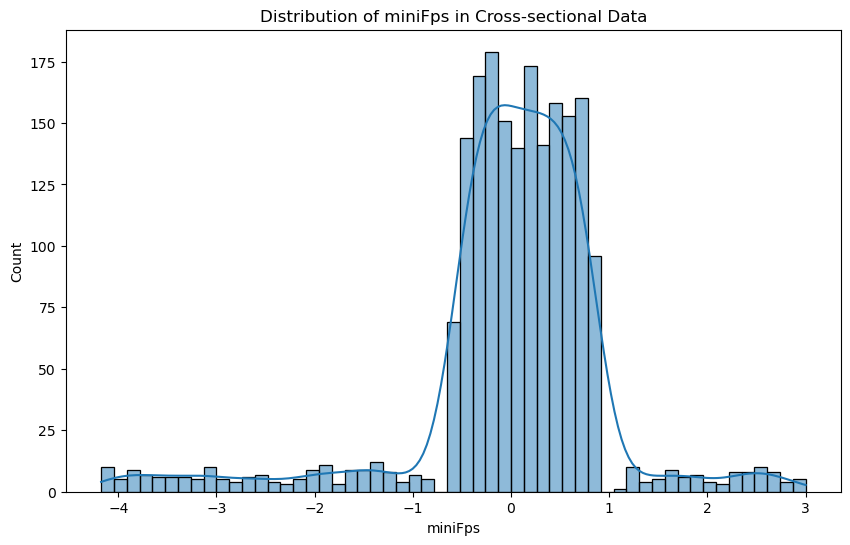

In [6]:
for feature in ['EyeQuality', 'DecodeErrCount', 'miniFps']:
    plt.figure(figsize=(10, 6))
    sns.histplot(cross_train_scaled[feature], kde=True)
    plt.title(f'Distribution of {feature} in Cross-sectional Data')
    plt.show()

In [7]:
#不同label下截面数据的分布观察
for feature in ['EyeQuality', 'DecodeErrCount', 'miniFps']:
    for i in range(1,5):
        mean_label=cross_train[cross_train['label']==i][feature].mean()
        std_label=cross_train[cross_train['label']==i][feature].std()
        print(f"Feature: {feature}, Label {i} - Mean: {mean_label}, Std: {std_label}")

Feature: EyeQuality, Label 1 - Mean: 168.378740248, Std: 5.483385638149364
Feature: EyeQuality, Label 2 - Mean: 161.925366222, Std: 6.010780542195113
Feature: EyeQuality, Label 3 - Mean: 157.46274627800003, Std: 6.169016664911348
Feature: EyeQuality, Label 4 - Mean: 154.345774786, Std: 6.3467321181145016
Feature: DecodeErrCount, Label 1 - Mean: 5.529285714285714, Std: 2.4408366494860183
Feature: DecodeErrCount, Label 2 - Mean: 12.803333333333333, Std: 4.018101461312321
Feature: DecodeErrCount, Label 3 - Mean: 14.875, Std: 4.404129514889361
Feature: DecodeErrCount, Label 4 - Mean: 23.49, Std: 12.476640800173968
Feature: miniFps, Label 1 - Mean: 10.451949886004286, Std: 0.4863452438774597
Feature: miniFps, Label 2 - Mean: 10.291950056693333, Std: 0.937108290235157
Feature: miniFps, Label 3 - Mean: 10.262737853574999, Std: 1.069890555973666
Feature: miniFps, Label 4 - Mean: 10.24180664832, Std: 1.1125041518963756


#### 时间序列数据处理

In [8]:
length_train = len(times_train['sample_id'])
length_test = len(times_test['sample_id'])
print(length_train, length_test)
sample_ids_train = times_train['sample_id'].unique()
sample_ids_test = times_test['sample_id'].unique()
times_train_new = times_train[['sample_id', 'label']].drop_duplicates()
times_test_new = times_test[['sample_id', 'label']].drop_duplicates()
def times_series_data_preprocessing(sample_ids,data,times_train_new):
#给出每个sample_id对应时间序列数据的分布
        for feature in ['Current','gpuUsage','cpuUsage','Current_diff1','gpuUsage_diff1','cpuUsage_diff1','Current_diff2','gpuUsage_diff2','cpuUsage_diff2']:
                for i in sample_ids:
                        sample_data=data[data['sample_id']==i]
                        mean=sample_data[feature].mean()
                        std=sample_data[feature].std()
                        max=sample_data[feature].max()
                        min=sample_data[feature].min()
                        model=LinearRegression()
                        X=sample_data[['time_idx']]
                        y=sample_data[feature]
                        model.fit(X,y)
                        slope=model.coef_[0]
                        skewness=y.skew()
                        kurtosis=y.kurtosis()
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_mean'] = mean
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_std'] = std
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_max'] = max
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_min'] = min
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_slope'] = slope
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_skewness'] = skewness
                        times_train_new.loc[times_train_new['sample_id']==i, f'{feature}_kurtosis'] = kurtosis
                        gpu_high_count = (sample_data['gpuUsage'] > 60).sum()
                        cpu_high_count = (sample_data['cpuUsage'] > 50).sum()
                        current_high_count = (sample_data['Current'] > 95).sum()
                        times_train_new.loc[times_train_new['sample_id']==i, 'gpu_high_count'] = gpu_high_count
                        times_train_new.loc[times_train_new['sample_id']==i, 'cpu_high_count'] = cpu_high_count
                        times_train_new.loc[times_train_new['sample_id']==i, 'current_high_count'] = current_high_count
        return times_train_new
times_train_new = times_series_data_preprocessing(sample_ids_train,times_train,times_train_new)
times_test_new = times_series_data_preprocessing(sample_ids_test,times_test,times_test_new)



120000 48000


feature_new = ['Current_mean','Current_std','Current_max','Current_min','Current_slope','Current_skewness','Current_kurtosis',
               'gpuUsage_mean','gpuUsage_std','gpuUsage_max','gpuUsage_min','gpuUsage_slope','gpuUsage_skewness','gpuUsage_kurtosis',
               'cpuUsage_mean','cpuUsage_std','cpuUsage_max','cpuUsage_min','cpuUsage_slope','cpuUsage_skewness','cpuUsage_kurtosis','cpu_high_count',
               'gpu_high_count','current_high_count']

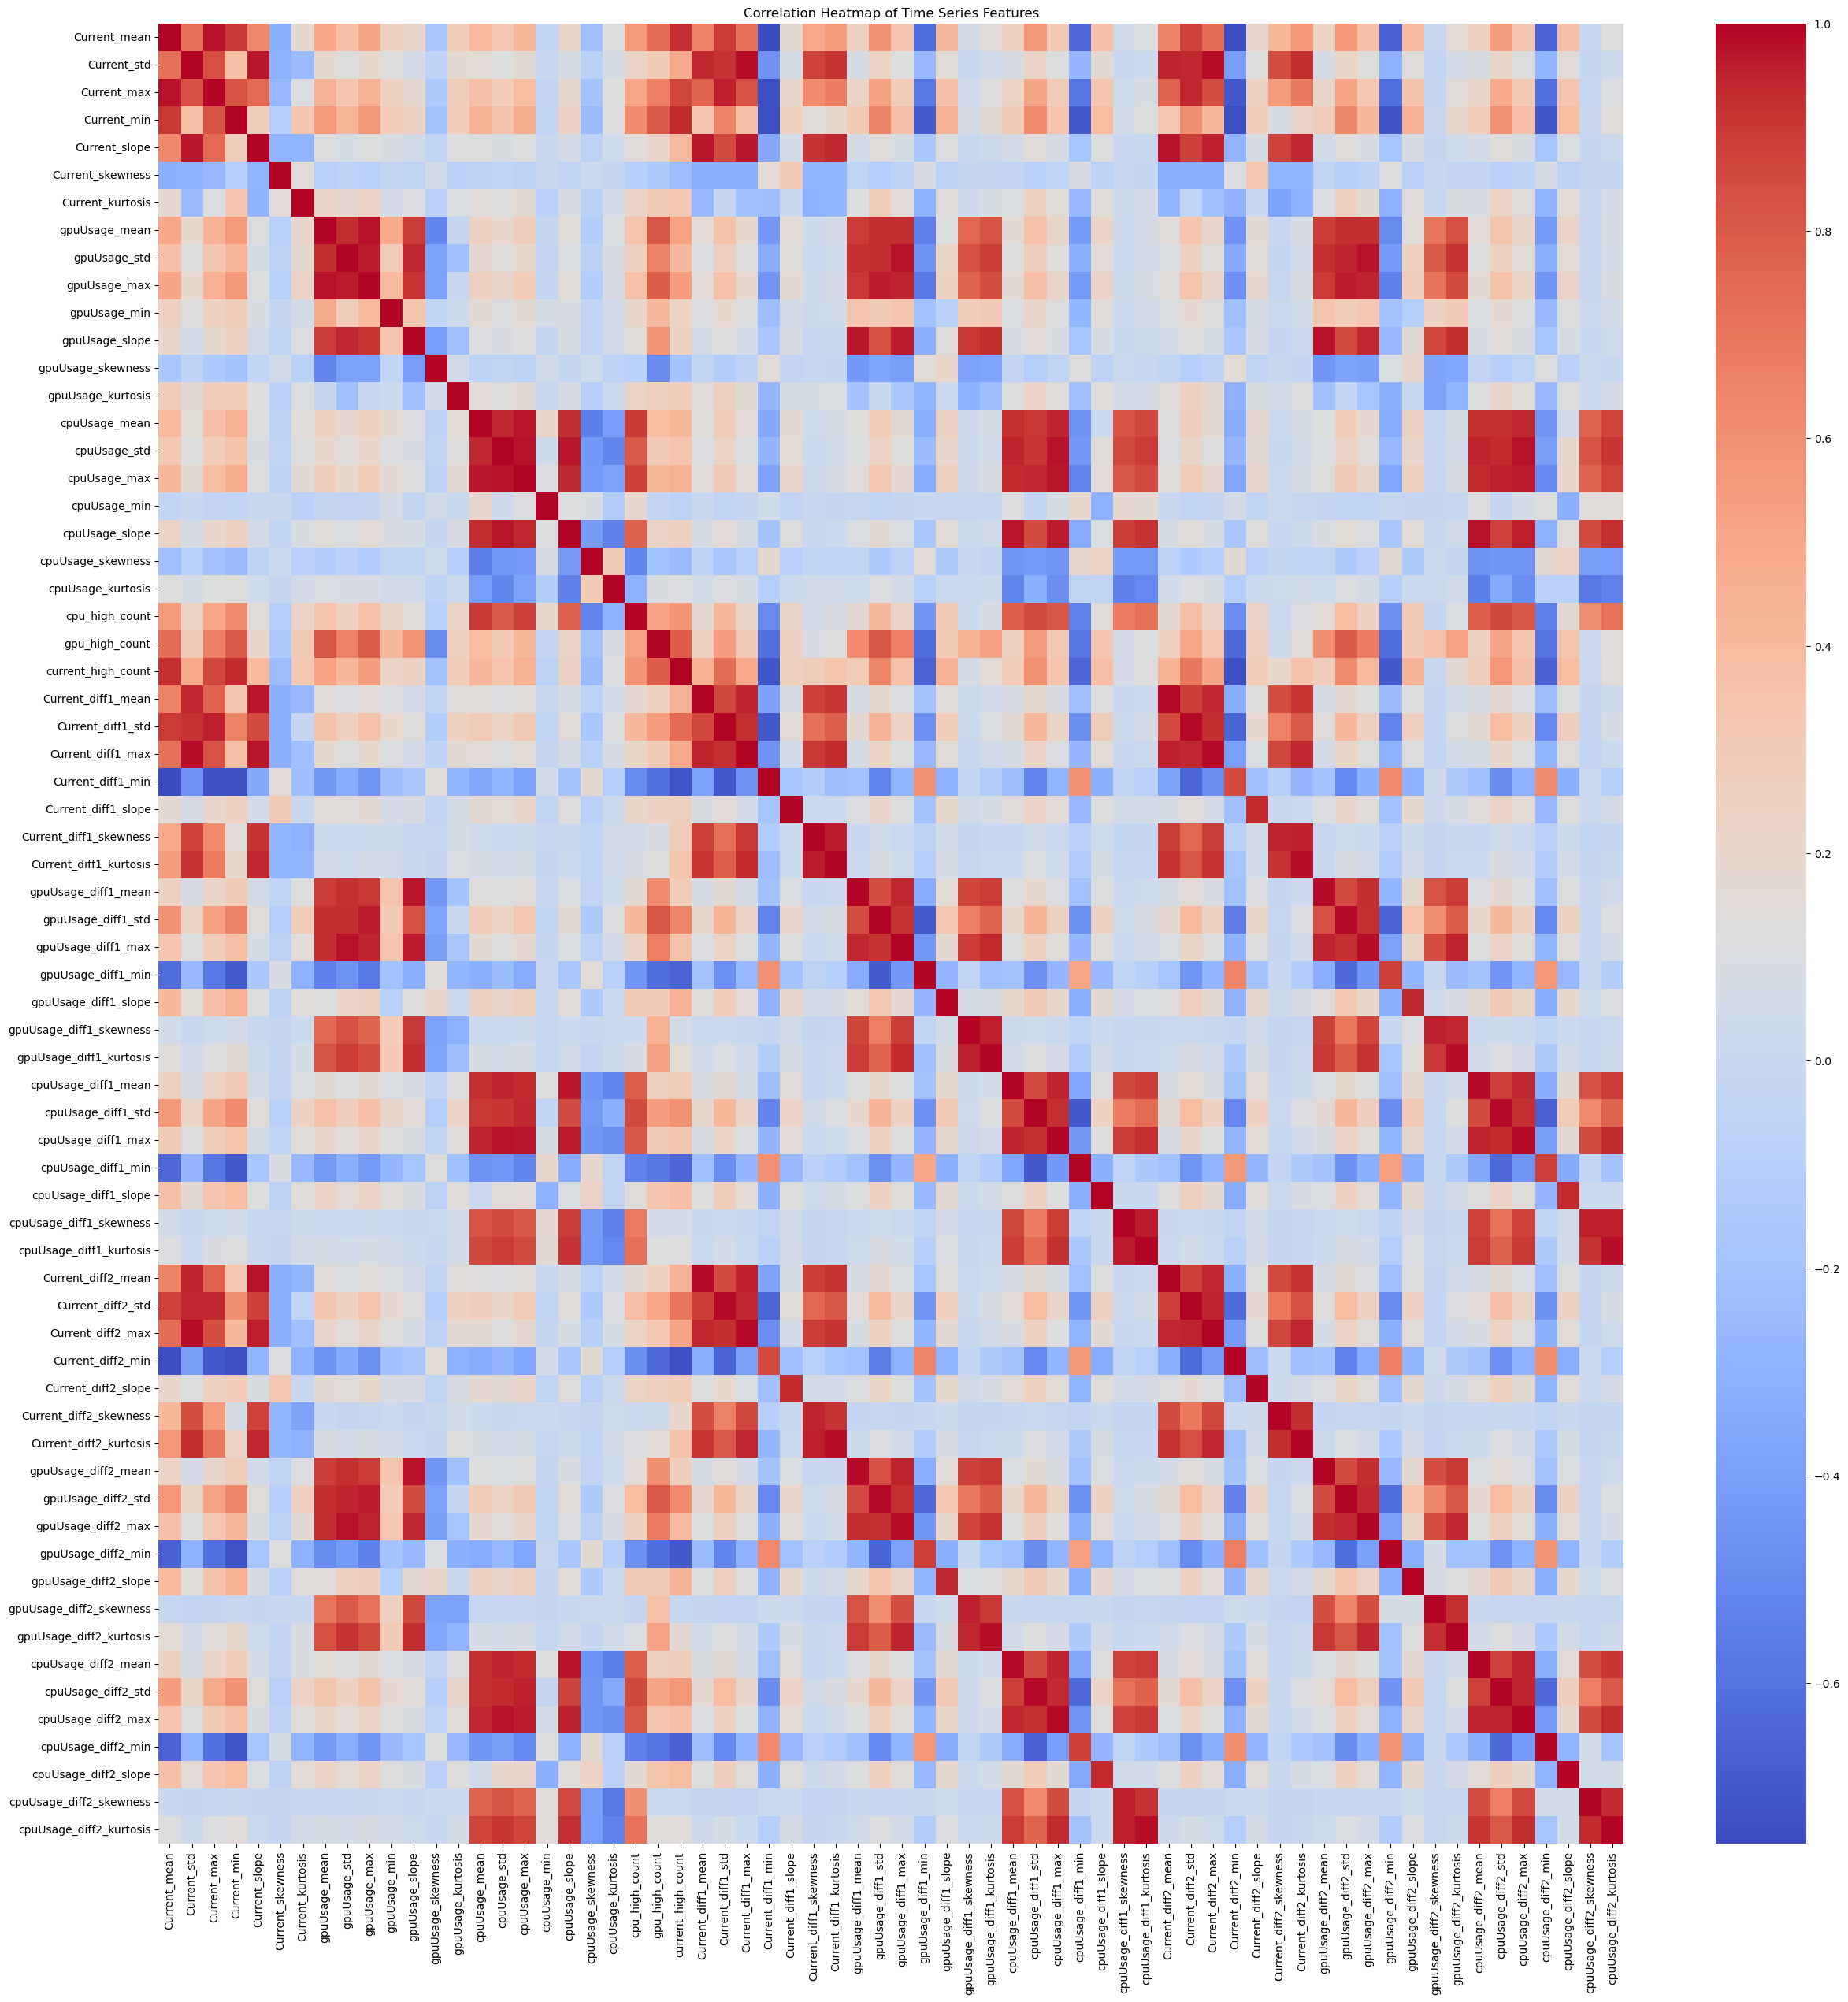

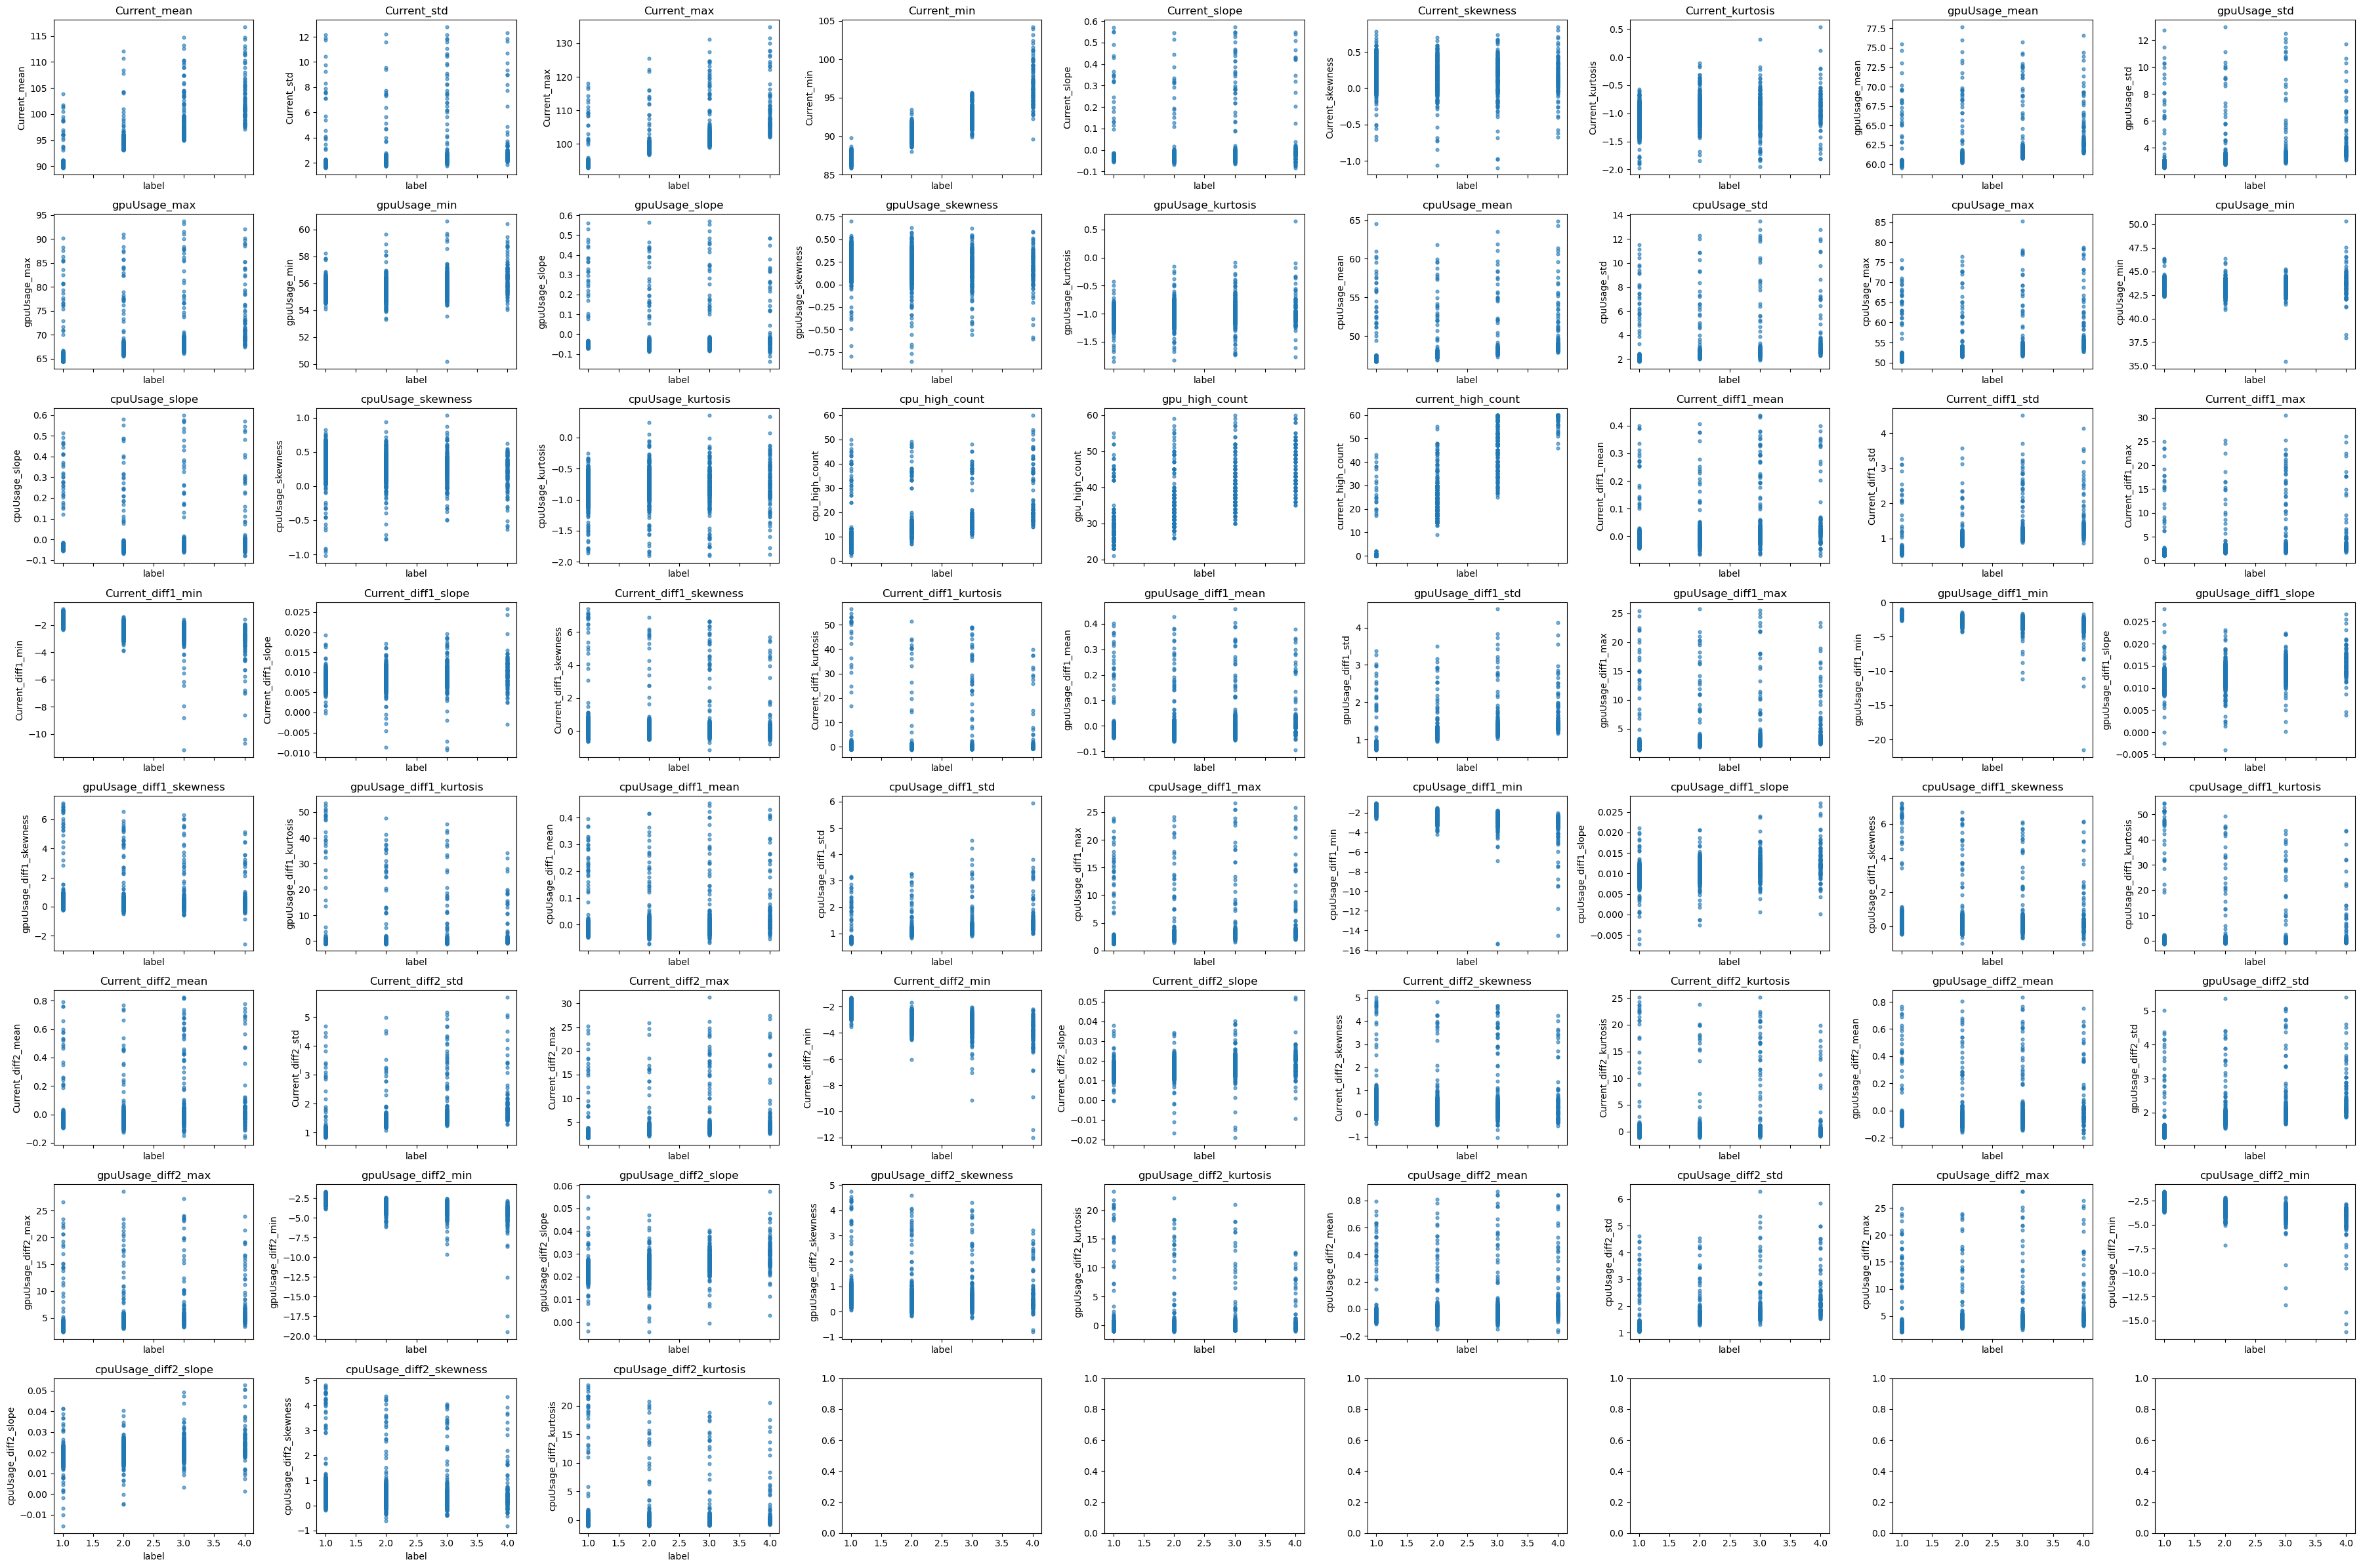

In [9]:
import math
feature_new = ['Current_mean','Current_std','Current_max','Current_min','Current_slope','Current_skewness','Current_kurtosis',
               'gpuUsage_mean','gpuUsage_std','gpuUsage_max','gpuUsage_min','gpuUsage_slope','gpuUsage_skewness','gpuUsage_kurtosis',
               'cpuUsage_mean','cpuUsage_std','cpuUsage_max','cpuUsage_min','cpuUsage_slope','cpuUsage_skewness','cpuUsage_kurtosis','cpu_high_count',
               'gpu_high_count','current_high_count',
               'Current_diff1_mean','Current_diff1_std','Current_diff1_max','Current_diff1_min','Current_diff1_slope','Current_diff1_skewness','Current_diff1_kurtosis',
               'gpuUsage_diff1_mean','gpuUsage_diff1_std','gpuUsage_diff1_max','gpuUsage_diff1_min','gpuUsage_diff1_slope','gpuUsage_diff1_skewness','gpuUsage_diff1_kurtosis',
               'cpuUsage_diff1_mean','cpuUsage_diff1_std','cpuUsage_diff1_max','cpuUsage_diff1_min','cpuUsage_diff1_slope','cpuUsage_diff1_skewness','cpuUsage_diff1_kurtosis',
               'Current_diff2_mean','Current_diff2_std','Current_diff2_max','Current_diff2_min','Current_diff2_slope','Current_diff2_skewness','Current_diff2_kurtosis',
               'gpuUsage_diff2_mean','gpuUsage_diff2_std','gpuUsage_diff2_max','gpuUsage_diff2_min','gpuUsage_diff2_slope','gpuUsage_diff2_skewness','gpuUsage_diff2_kurtosis',
               'cpuUsage_diff2_mean','cpuUsage_diff2_std','cpuUsage_diff2_max','cpuUsage_diff2_min','cpuUsage_diff2_slope','cpuUsage_diff2_skewness','cpuUsage_diff2_kurtosis']
plt.figure(figsize=(30, 30))
sns.heatmap(times_train_new[feature_new].corr(), annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Time Series Features')
plt.show()
len_feature = len(feature_new)

nrows = 8
ncols = math.ceil(len_feature / nrows)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
axes = axes.flatten()

for idx, feature in enumerate(feature_new):
    ax = axes[idx]
    ax.scatter(times_train_new['label'], times_train_new[feature], alpha=0.6, s=12)
    ax.set_title(feature)
    ax.set_xlabel('label')
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()


#### 时间序列数据和截面数据合并

In [10]:
train_df_new= pd.merge(times_train_new, cross_train, on=['sample_id', 'label'])
test_df_new= pd.merge(times_test_new, cross_test, on=['sample_id', 'label'])
train_df_new.head()
train_df_new.describe()

,sample_id,label,Current_mean,Current_std,Current_max,Current_min,Current_slope,Current_skewness,Current_kurtosis,gpu_high_count,...,cpuUsage_diff2_mean,cpuUsage_diff2_std,cpuUsage_diff2_max,cpuUsage_diff2_min,cpuUsage_diff2_slope,cpuUsage_diff2_skewness,cpuUsage_diff2_kurtosis,EyeQuality,DecodeErrCount,miniFps
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000
mean,1000.500000,1.500000,92.540557,2.291605,96.757954,88.739749,-0.015919,0.209409,-1.092154,30.996000,...,-0.016717,1.468805,3.882180,-2.760619,0.019115,0.567559,0.486028,165.617486,8.4530,10.398522
std,577.494589,0.866242,4.012596,1.300312,5.564117,2.740537,0.080047,0.184418,0.224960,6.773103,...,0.122915,0.529111,3.076052,0.986066,0.004389,0.665181,3.155613,7.254305,6.3631,0.692035
min,1.000000,1.000000,89.728050,1.612864,92.821319,85.902986,-0.082605,-1.094296,-1.968219,21.000000,...,-0.171913,1.027064,2.010991,-16.214281,-0.015425,-0.823214,-1.075306,135.084860,0.0000,7.510381
25%,500.750000,1.000000,90.234523,1.893910,93.780567,87.106964,-0.037216,0.125043,-1.228486,27.000000,...,-0.058173,1.215864,2.761915,-3.093210,0.017044,0.292212,-0.462080,161.110687,5.0000,10.188627
50%,1000.500000,1.000000,90.595665,1.987931,94.234436,87.492433,-0.031856,0.217489,-1.118616,28.000000,...,-0.042293,1.283122,3.099113,-2.497919,0.018687,0.469040,-0.181544,166.233942,7.0000,10.472957
75%,1500.250000,2.000000,94.059282,2.181712,98.464148,89.961145,-0.026205,0.323596,-0.985276,33.000000,...,-0.025273,1.587146,3.728576,-2.207313,0.020493,0.637582,0.182984,171.049208,11.0000,10.760410
max,2000.000000,4.000000,116.710144,12.777623,134.889391,104.194018,0.573022,0.842790,0.539455,60.000000,...,0.869481,6.293724,28.099897,-1.496012,0.052695,4.803101,23.627468,179.918214,69.0000,12.475154


In [11]:
def cross_feature_engineering(train_df_new):
    cpu_vola=train_df_new['cpuUsage_std']/train_df_new['cpuUsage_mean']*(180-train_df_new['EyeQuality'])
    train_df_new['cpu_vola']=cpu_vola
    gpu_vola=train_df_new['gpuUsage_std']/train_df_new['gpuUsage_mean']*(180-train_df_new['EyeQuality'])
    train_df_new['gpu_vola']=gpu_vola
    current_decode=abs(train_df_new['Current_slope'])*train_df_new['DecodeErrCount']*10
    train_df_new['Current_decode']=current_decode
    return train_df_new
train_df_new = cross_feature_engineering(train_df_new)
test_df_new = cross_feature_engineering(test_df_new)
train_df_new['cpu*gpu']=train_df_new['cpuUsage_mean']*train_df_new['gpuUsage_mean']
test_df_new['cpu*gpu']=test_df_new['cpuUsage_mean']*test_df_new['gpuUsage_mean']

def smote_oversampling(X, y):
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled

X_train_final = train_df_new[feature_new+['EyeQuality','DecodeErrCount','miniFps']]
y_train_final = train_df_new['label']
X_test_final = test_df_new[feature_new+['EyeQuality','DecodeErrCount','miniFps']]
y_test_final = test_df_new['label']
X_train_final, y_train_final = smote_oversampling(X_train_final, y_train_final)



## 2. 模型对比选择与训练
#### 随机森林（Random Forest）
- 选择重要度排名前12的数据特征作为输入进行随机森林模型训练
- 使用K折交叉验证与网格搜索确定随机森林模型参数（n_estimator等）
- 使用SMOTE过采样生成标签2、3和4的样本缓解不平衡性
- 用未过采样的数据集训练LightGBM模型，自动分配权重，与随机森林模型叠加输出预测结果，叠加权重也由网格搜索确定。

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(X_train_final, y_train_final)
y_pred = rf_classifier.predict(X_test_final)
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
K = 12
selected_features = [X_train_final.columns[i] for i in indices[:K]]
print("Top K important features:")
for feature in selected_features:
    print(feature)
X_train_selected = X_train_final[selected_features]
X_test_selected = X_test_final[selected_features]
rf_classifier_selected = RandomForestClassifier(
    n_estimators=200, 
    random_state=42,
    class_weight = 'balanced'
    )

rf_classifier_selected.fit(X_train_selected, y_train_final)
y_pred = rf_classifier_selected.predict(X_test_selected)
print("Classification Report:")
print(classification_report(y_test_final, y_pred))

rf_proba = rf_classifier_selected.predict_proba(X_test_selected)
print("Random Forest Classifier Probabilities:")
print(rf_proba[:10])

lgbm_classifier = lgb.LGBMClassifier(
    n_estimators=200,
    random_state=42,
    num_class=4,
    learning_rate=0.05,
    class_weight = 'balanced'
    )
lgbm_classifier.fit(X_train_selected, y_train_final)
y_pred_lgbm = lgbm_classifier.predict(X_test_selected)
print("LGBM Classifier Classification Report:")
print(classification_report(y_test_final, y_pred_lgbm))
lgbm_proba = lgbm_classifier.predict_proba(X_test_selected)
print("LGBM Classifier Probabilities:")
print(lgbm_proba[:10])

rf_weights = np.arange(0, 1.1, 0.1)
best_score = -1
best_rf_weight = 0.5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for rf_weight in rf_weights:
    lgbm_weight = 1 - rf_weight
    final_proba = (rf_weight * rf_proba) + (lgbm_weight * lgbm_proba)
    final_pred = np.argmax(final_proba, axis=1) + 1
    report = classification_report(y_test_final, final_pred, output_dict=True)
    f1_score = report['weighted avg']['f1-score']
    if f1_score > best_score:
        best_score = f1_score
        best_rf_weight = rf_weight

print(f"Best RF Weight: {best_rf_weight}, Best F1 Score: {best_score}")
rf_weight = best_rf_weight
lgbm_weight = 1 - best_rf_weight
final_proba = (rf_weight * rf_proba) + (lgbm_weight * lgbm_proba)
final_pred = np.argmax(final_proba, axis=1) + 1
print("Ensembled Classifier Classification Report:")
print(classification_report(y_test_final, final_pred))


Top K important features:
Current_mean
Current_min
current_high_count
Current_max
gpuUsage_mean
cpuUsage_mean
Current_diff1_std
gpuUsage_max
cpuUsage_diff1_std
gpuUsage_diff1_std
Current_diff2_std
gpuUsage_diff2_std
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200
           2       0.93      0.83      0.88       200
           3       0.71      0.89      0.79       200
           4       0.95      0.81      0.87       200

    accuracy                           0.88       800
   macro avg       0.90      0.88      0.89       800
weighted avg       0.90      0.88      0.89       800

Random Forest Classifier Probabilities:
[[0.    0.    0.08  0.92 ]
 [0.005 0.18  0.815 0.   ]
 [0.    0.24  0.76  0.   ]
 [0.    0.065 0.92  0.015]
 [0.    1.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    0.925 0.075]
 [0.    0.995 0.005 0.   ]
 [1.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]]
[LightGBM] [Inf

随机森林模型结果可视化

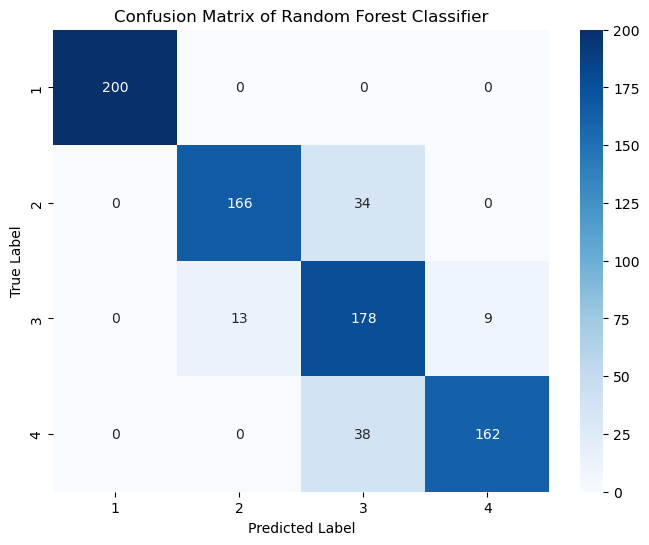

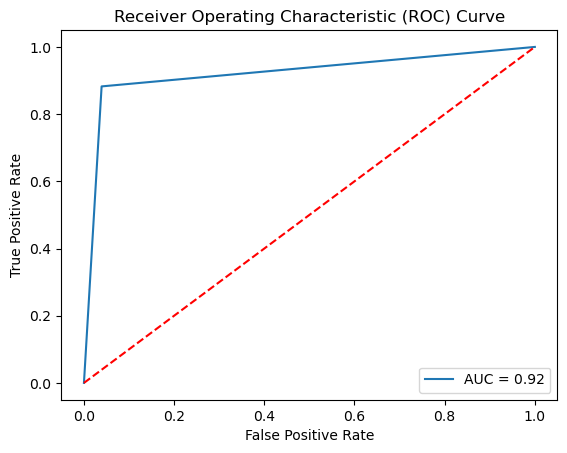

In [13]:

#绘制混淆矩阵
import seaborn as sns
cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Random Forest Classifier')
plt.show()

from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test_final)
y_pred_binarized = lb.transform(y_pred)
fpr,tpr,_=roc_curve(y_test_binarized.ravel(), y_pred_binarized.ravel())
auc_score=auc(fpr,tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


Cross-Validation Scores: [0.99285714 0.99142857 0.98857143 0.96428571 0.98142857 0.96714286
 0.99142857 0.96571429]
Mean CV Score: 0.9803571428571429
Best Parameters from Grid Search: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200
           2       0.93      0.83      0.88       200
           3       0.71      0.89      0.79       200
           4       0.95      0.81      0.87       200

    accuracy                           0.88       800
   macro avg       0.90      0.88      0.89       800
weighted avg       0.90      0.88      0.89       800



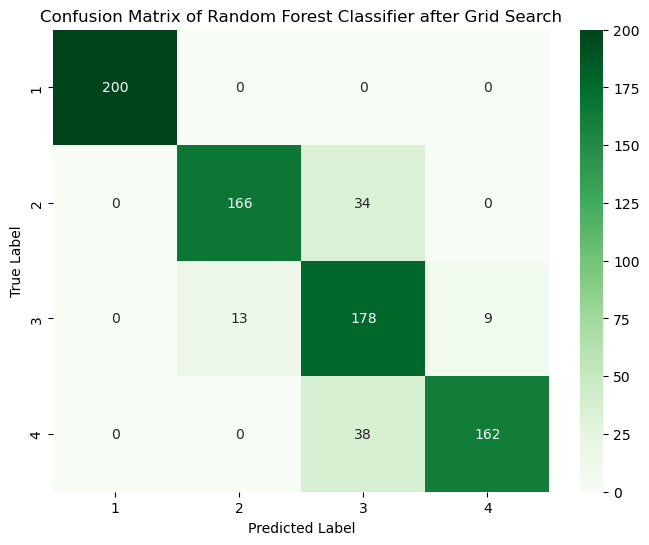

In [14]:
#8折交叉验证
K_fold=KFold(n_splits=8)
cv_scores = cross_val_score(rf_classifier_selected, X_train_selected, y_train_final, cv=K_fold)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))
#网格搜索
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}
grid_search = GridSearchCV(estimator=rf_classifier_selected, param_grid=param_grid, cv=K_fold, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_selected, y_train_final)
print("Best Parameters from Grid Search:", grid_search.best_params_)
best_rf_classifier = grid_search.best_estimator_
y_pred = best_rf_classifier.predict(X_test_selected)
print("Classification Report:")
print(classification_report(y_test_final, y_pred))
confusion_mtx = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Greens', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Random Forest Classifier after Grid Search')
plt.show()

#### Adaboost
准确率低于随机森林

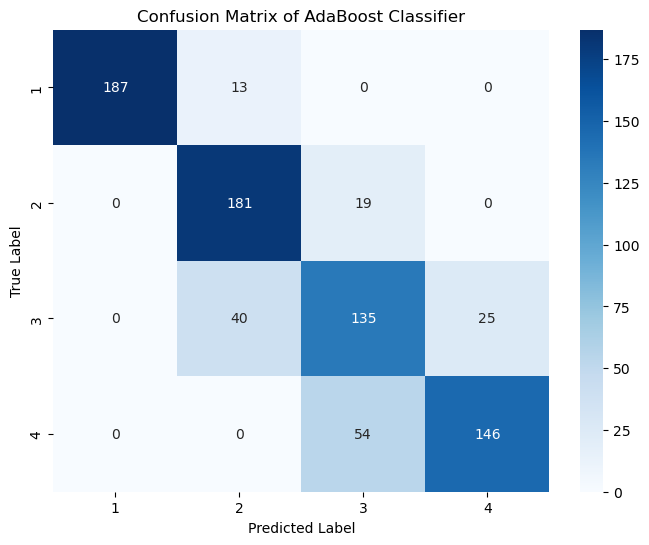

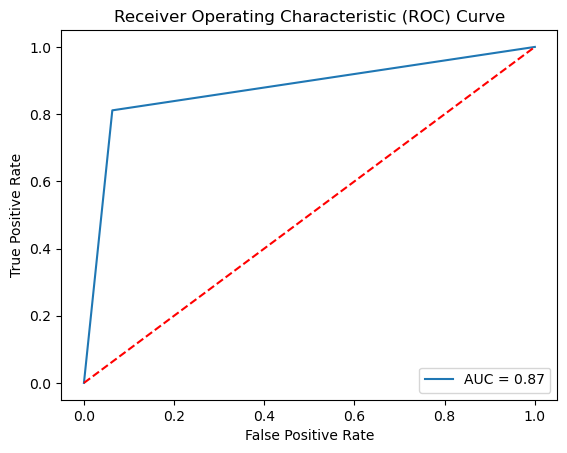

Classification Report for AdaBoost:
              precision    recall  f1-score   support

           1       1.00      0.94      0.97       200
           2       0.77      0.91      0.83       200
           3       0.65      0.68      0.66       200
           4       0.85      0.73      0.79       200

    accuracy                           0.81       800
   macro avg       0.82      0.81      0.81       800
weighted avg       0.82      0.81      0.81       800



In [15]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_final, y_train_final)
y_pred_ada = ada.predict(X_test_final)

import seaborn as sns
cm = confusion_matrix(y_test_final, y_pred_ada)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of AdaBoost Classifier')
plt.show()

from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test_final)
y_pred_ada_binarized = lb.transform(y_pred_ada)
fpr,tpr,_=roc_curve(y_test_binarized.ravel(), y_pred_ada_binarized.ravel())
auc_score=auc(fpr,tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print("Classification Report for AdaBoost:")
print(classification_report(y_test_final, y_pred_ada))

#### Decision Tree
准确率低于随机森林

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           1       0.97      0.99      0.98       200
           2       0.87      0.84      0.86       200
           3       0.68      0.83      0.75       200
           4       0.92      0.72      0.81       200

    accuracy                           0.85       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.85      0.85       800



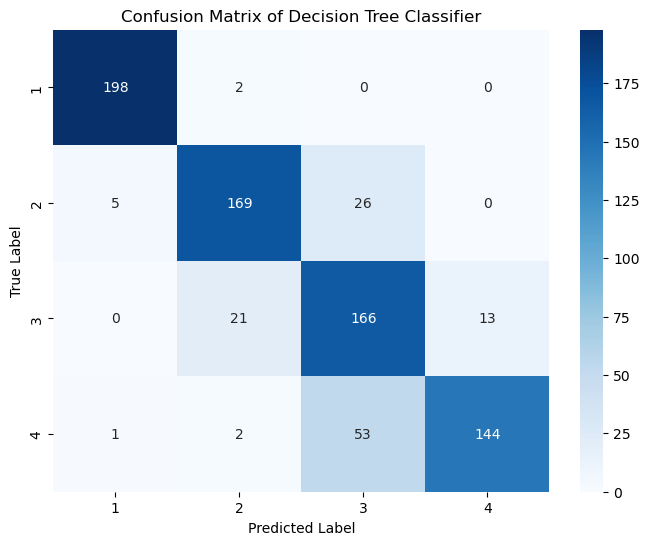

In [16]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_final, y_train_final)
y_pred_dt = dt_classifier.predict(X_test_final)
print("Classification Report for Decision Tree:")
print(classification_report(y_test_final, y_pred_dt))
plt.figure(figsize=(8, 6))
confusion_matrix_dt = confusion_matrix(y_test_final, y_pred_dt)
sns.heatmap(confusion_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Decision Tree Classifier')
plt.show()

#### Gradient Boosting
选择重要度前15的特征，准确率0.91略高于随机森林模型，分析见Final Report。

Top 15 important features:
Current_min
Current_mean
current_high_count
Current_slope
Current_max
gpuUsage_mean
cpu_high_count
DecodeErrCount
cpuUsage_mean
gpuUsage_kurtosis
cpuUsage_max
gpuUsage_std
cpuUsage_diff1_mean
gpuUsage_slope
Current_diff1_mean
Classification Report:
              precision    recall  f1-score   support

           1       0.99      1.00      0.99       200
           2       0.94      0.89      0.92       200
           3       0.79      0.86      0.83       200
           4       0.92      0.87      0.89       200

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200
           2       0.94      0.89      0.91       200
           3       0.75      0.88      0.81       200
           4       0.92    

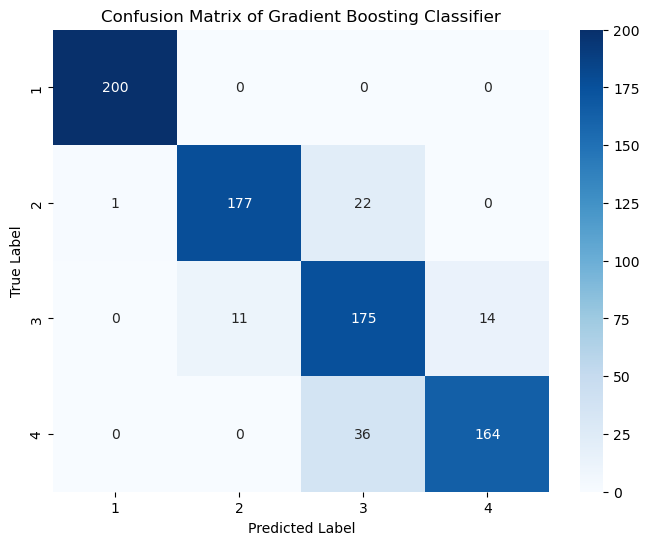

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_classifier.fit(X_train_final, y_train_final)
y_pred_gd=gb_classifier.predict(X_test_final)
importances = gb_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
K = 15
selected_features = [X_train_final.columns[i] for i in indices[:K]]
print(f"Top {K} important features:")
for feature in selected_features:
    print(feature)
X_train_selected = X_train_final[selected_features]
X_test_selected = X_test_final[selected_features]
gb_classifier_selected = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_classifier_selected.fit(X_train_selected, y_train_final)
y_pred = gb_classifier_selected.predict(X_test_selected)
print("Classification Report:")
print(classification_report(y_test_final, y_pred))
print("Classification Report for Gradient Boosting:")
print(classification_report(y_test_final,y_pred_gd))
confusion_matrix_gb = confusion_matrix(y_test_final, y_pred_gd)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_gb, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Gradient Boosting Classifier')
plt.show()

Cross-Validation Scores: [0.98857143 0.99428571 0.98571429 0.97857143 0.99       0.97857143
 0.98714286 0.97285714]
Mean CV Score: 0.9844642857142858
Best Parameters from Grid Search: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200
           2       0.95      0.88      0.91       200
           3       0.75      0.89      0.81       200
           4       0.93      0.82      0.87       200

    accuracy                           0.90       800
   macro avg       0.91      0.90      0.90       800
weighted avg       0.91      0.90      0.90       800



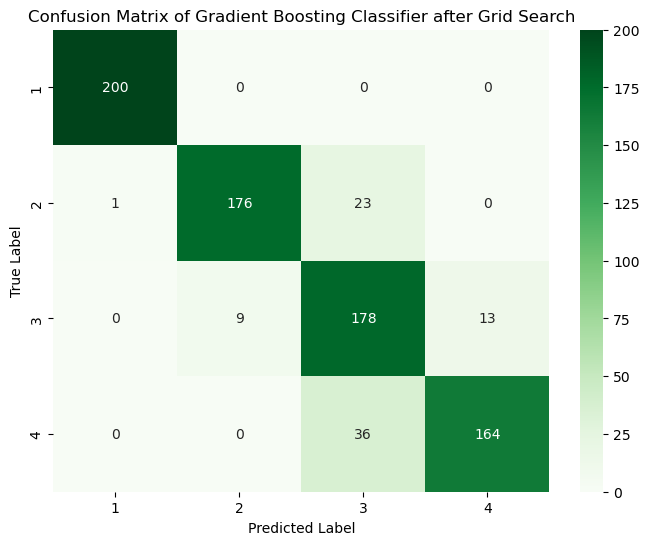

In [18]:
#交叉验证和网格搜索
K_fold=KFold(n_splits=8)
cv_scores = cross_val_score(gb_classifier_selected, X_train_selected, y_train_final, cv=K_fold)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))
#网格搜索
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=gb_classifier_selected, param_grid=param_grid, cv=K_fold, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_selected, y_train_final)
print("Best Parameters from Grid Search:", grid_search.best_params_)
best_gb_classifier = grid_search.best_estimator_
y_pred = best_gb_classifier.predict(X_test_selected)
print("Classification Report:")
print(classification_report(y_test_final, y_pred))
confusion_mtx = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Greens', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Gradient Boosting Classifier after Grid Search')
plt.show()

#### KNN
准确率低于随机森林

Best Parameters for KNN from Grid Search: {'n_neighbors': 3}
Classification Report for KNN:
              precision    recall  f1-score   support

           1       1.00      0.99      1.00       200
           2       0.87      0.81      0.83       200
           3       0.61      0.73      0.66       200
           4       0.83      0.72      0.78       200

    accuracy                           0.81       800
   macro avg       0.83      0.81      0.82       800
weighted avg       0.83      0.81      0.82       800



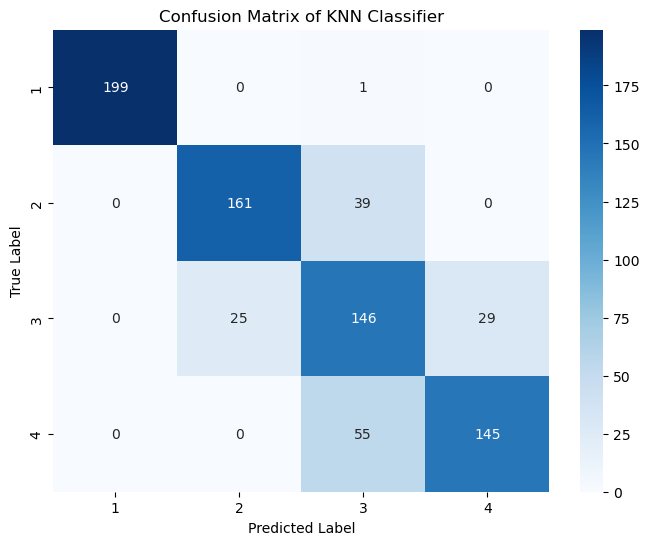

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
grid_knn=GridSearchCV(estimator=knn_classifier, param_grid={'n_neighbors':[3,5,7,9]}, cv=K_fold, n_jobs=-1, scoring='accuracy')
grid_knn.fit(X_train_final, y_train_final)
y_pred_knn=grid_knn.predict(X_test_final)
print("Best Parameters for KNN from Grid Search:", grid_knn.best_params_)
print("Classification Report for KNN:")
print(classification_report(y_test_final,y_pred_knn))
confusion_matrix_knn = confusion_matrix(y_test_final, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNN Classifier')
plt.show()